# Demo Notebook

## Install Dependicies on HiPerGator

In [ ]:
%pip install datasets transformers scikit-learn matplotlib seaborn --quiet

## Imports

In [11]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import warnings
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

LABEL_NAMES = ['background', 'objective', 'methods', 'results', 'conclusions']
LABEL2IDX   = {l: i for i, l in enumerate(LABEL_NAMES)}
IDX2LABEL   = {i: l for l, i in LABEL2IDX.items()}
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {device}')

Device: cuda


## Config + LSTM Model Definition

In [2]:
CONFIG = {
    'max_len'    : 128,
    'batch_size' : 64,
    'num_classes': 5,
    'vocab_size' : 30000,
    'embed_dim'  : 128,
    'hidden_dim' : 256,
    'num_layers' : 2,
    'dropout'    : 0.3,
}

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

print('Config and model class ready.')

Config and model class ready.


## Load Data + Rebuild Vocab

In [3]:
ds = load_dataset('armanc/pubmed-rct20k')

train_df = ds['train'].to_pandas()
test_df  = ds['test'].to_pandas()

train_df['label_idx'] = train_df['label'].map(LABEL2IDX)
test_df['label_idx']  = test_df['label'].map(LABEL2IDX)

# Rebuild vocab from training set (must match training notebook exactly)
def build_vocab(texts, max_vocab_size):
    counter = Counter()
    for text in texts:
        counter.update(text.lower().split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab_size - 2):
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train_df['text'].tolist(), CONFIG['vocab_size'])
print(f'Vocab size: {len(vocab):,}')
print(f'Test set  : {len(test_df):,} sentences')

Repo card metadata block was not found. Setting CardData to empty.


Vocab size: 30,000
Test set  : 29,578 sentences


## Load LSTM Checkpoint

In [4]:
lstm_model = LSTMClassifier(
    vocab_size  = len(vocab),
    embed_dim   = CONFIG['embed_dim'],
    hidden_dim  = CONFIG['hidden_dim'],
    num_layers  = CONFIG['num_layers'],
    num_classes = CONFIG['num_classes'],
    dropout     = CONFIG['dropout']
).to(device)

lstm_model.load_state_dict(torch.load('models/lstm_best.pt', map_location=device))
lstm_model.eval()
print('LSTM loaded.')

LSTM loaded.


## Load DistilBERT Checkpoint

In [5]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=CONFIG['num_classes']
).to(device)

bert_model.load_state_dict(torch.load('models/bert_best.pt', map_location=device))
bert_model.eval()
print('DistilBERT loaded.')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 28189.42it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded.


## Single Sentence Inference Helper Function

In [6]:
def predict_lstm(sentence, model, vocab, max_len):
    tokens = sentence.lower().split()[:max_len]
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    input_tensor = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(input_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    return IDX2LABEL[np.argmax(probs)], probs

def predict_bert(sentence, model, tokenizer, max_len):
    encoding = tokenizer(
        sentence,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    return IDX2LABEL[np.argmax(probs)], probs

print('Inference functions ready.')

Inference functions ready.


## Predict On Real Examples

In [7]:
test_sentences = [
    ("Patients with type 2 diabetes have an increased risk of cardiovascular disease.",
     "background"),
    ("The aim of this study was to evaluate the efficacy of metformin in reducing HbA1c levels.",
     "objective"),
    ("Participants were randomly assigned to receive either 500mg metformin or placebo twice daily for 12 weeks.",
     "methods"),
    ("HbA1c levels were significantly reduced in the metformin group compared to placebo ( p < 0.01 ).",
     "results"),
    ("Metformin is an effective and well-tolerated treatment for glycemic control in type 2 diabetes patients.",
     "conclusions"),
]

print(f'{"Sentence":<70} {"True":<12} {"LSTM":<12} {"BERT":<12}')
print('-' * 110)

for sentence, true_label in test_sentences:
    lstm_pred, _ = predict_lstm(sentence, lstm_model, vocab, CONFIG['max_len'])
    bert_pred, _ = predict_bert(sentence, bert_model, tokenizer, CONFIG['max_len'])
    lstm_mark = '✓' if lstm_pred == true_label else '✗'
    bert_mark = '✓' if bert_pred == true_label else '✗'
    print(f'{sentence[:68]:<70} {true_label:<12} {lstm_pred+" "+lstm_mark:<12} {bert_pred+" "+bert_mark:<12}')

Sentence                                                               True         LSTM         BERT        
--------------------------------------------------------------------------------------------------------------
Patients with type 2 diabetes have an increased risk of cardiovascul   background   background ✓ background ✓
The aim of this study was to evaluate the efficacy of metformin in r   objective    objective ✓  objective ✓ 
Participants were randomly assigned to receive either 500mg metformi   methods      methods ✓    methods ✓   
HbA1c levels were significantly reduced in the metformin group compa   results      results ✓    results ✓   
Metformin is an effective and well-tolerated treatment for glycemic    conclusions  conclusions ✓ conclusions ✓


## Confidence Visualization For One Sentence

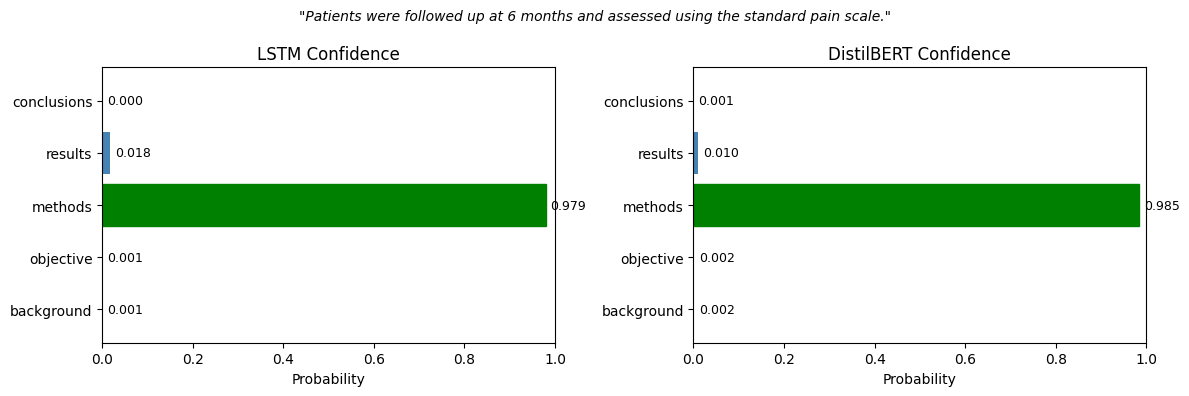

In [9]:
sentence = "Patients were followed up at 6 months and assessed using the standard pain scale."
true_label = "methods"

_, lstm_probs = predict_lstm(sentence, lstm_model, vocab, CONFIG['max_len'])
_, bert_probs = predict_bert(sentence, bert_model, tokenizer, CONFIG['max_len'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, probs, title in zip(axes,
                             [lstm_probs, bert_probs],
                             ['LSTM', 'DistilBERT']):
    bars = ax.barh(LABEL_NAMES, probs, color='steelblue')
    bars[LABEL_NAMES.index(true_label)].set_color('green')
    ax.set_xlim(0, 1)
    ax.set_title(f'{title} Confidence')
    ax.set_xlabel('Probability')
    for i, p in enumerate(probs):
        ax.text(p + 0.01, i, f'{p:.3f}', va='center', fontsize=9)

plt.suptitle(f'"{sentence}"', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('figures/confidence_plot.png', bbox_inches='tight')
plt.show()

## Error Analysis

In [10]:
# Sample some cases where LSTM and BERT disagree

class LSTMDataset(Dataset):
    def __init__(self, df, vocab, max_len):
        self.texts  = df['text'].tolist()
        self.labels = df['label_idx'].tolist()
        self.vocab  = vocab
        self.max_len = max_len

    def encode(self, text):
        tokens = text.lower().split()[:self.max_len]
        ids = [self.vocab.get(t, self.vocab['<UNK>']) for t in tokens]
        ids += [self.vocab['<PAD>']] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        return self.encode(self.texts[idx]), torch.tensor(self.labels[idx], dtype=torch.long)

class BertDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts   = df['text'].tolist()
        self.labels  = df['label_idx'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

test_lstm_ds = LSTMDataset(test_df, vocab, CONFIG['max_len'])
test_bert_ds = BertDataset(test_df, tokenizer, CONFIG['max_len'])
test_loader_lstm = DataLoader(test_lstm_ds, batch_size=CONFIG['batch_size'])
test_loader_bert = DataLoader(test_bert_ds, batch_size=CONFIG['batch_size'])

# Get all predictions
lstm_preds, bert_preds, true_labels = [], [], []

lstm_model.eval()
with torch.no_grad():
    for inputs, labels in test_loader_lstm:
        inputs = inputs.to(device)
        preds = lstm_model(inputs).argmax(1).cpu().numpy()
        lstm_preds.extend(preds)
        true_labels.extend(labels.numpy())

bert_preds = []
bert_model.eval()
with torch.no_grad():
    for batch in test_loader_bert:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(1).cpu().numpy()
        bert_preds.extend(preds)

lstm_preds = np.array(lstm_preds)
bert_preds = np.array(bert_preds)
true_labels = np.array(true_labels)

# Find disagreements
disagree_mask = lstm_preds != bert_preds
print(f'Total disagreements: {disagree_mask.sum():,} / {len(true_labels):,} ({disagree_mask.mean()*100:.1f}%)\n')

# Sample 10 disagreements and show who was right
disagree_df = test_df[disagree_mask].copy()
disagree_df['true']      = true_labels[disagree_mask]
disagree_df['lstm_pred'] = lstm_preds[disagree_mask]
disagree_df['bert_pred'] = bert_preds[disagree_mask]
disagree_df['lstm_right'] = disagree_df['true'] == disagree_df['lstm_pred']
disagree_df['bert_right'] = disagree_df['true'] == disagree_df['bert_pred']

sample = disagree_df.sample(10, random_state=42)
print(f'{"Text":<65} {"True":<12} {"LSTM":<12} {"BERT":<12} {"Who won"}')
print('-' * 115)
for _, row in sample.iterrows():
    winner = 'BERT' if row['bert_right'] else ('LSTM' if row['lstm_right'] else 'neither')
    print(f'{row["text"][:63]:<65} '
          f'{IDX2LABEL[row["true"]]:<12} '
          f'{IDX2LABEL[row["lstm_pred"]]:<12} '
          f'{IDX2LABEL[row["bert_pred"]]:<12} '
          f'{winner}')

Total disagreements: 3,109 / 29,578 (10.5%)

Text                                                              True         LSTM         BERT         Who won
-------------------------------------------------------------------------------------------------------------------
Maintaining LMA cuff pressure in values which do not exceed @ c   conclusions  background   conclusions  BERT
Rituximab was safe and effective in @ of @ patients with noninf   conclusions  conclusions  results      LSTM
This study aimed to evaluate the clinical outcomes of CBT in fe   objective    objective    background   LSTM
This analysis evaluates the mystical-type effects of ketamine ,   background   background   objective    LSTM
Fecal donor and time of UC appear to affect outcomes .            conclusions  background   conclusions  BERT
The Bypass Angioplasty Revascularization Investigation @ Diabet   background   background   objective    LSTM
This was a triple-blind ( patient , physician , and statisticia   

## Demo Summary

### Inference Results
- Both models correctly classified all 5 hand-picked test sentences
- Both models showed high confidence on clear-cut examples (methods: 0.979 LSTM, 0.985 DistilBERT)

### Model Disagreement Analysis
- Models disagree on 10.5% of test sentences (3,109 / 29,578)
- Most disagreements occur on background vs objective boundaries - both are intro-style sentences with similar vocabulary
- When models disagree, BERT tends to win more often due to richer contextual understanding
- Common LSTM failure: misclassifying conclusions as background (e.g. "Maintaining LMA cuff pressure...")
- Common BERT failure: misclassifying conclusions as results on numeric/statistical sentences
- "Neither" correct cases represent genuinely ambiguous sentences that challenge both models

### Takeaway
- For straightforward sentences both models perform identically
- DistilBERT has an edge on ambiguous boundary cases
- The LSTM remains a strong lightweight option when compute is limited